In [1]:
import numpy as np
import tifffile as tiff
from scipy.stats import pearsonr
import pandas as pd
import os
import pandas as pd
from tifffile import imread
from pathlib import Path
import os
import pickle
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import sem, ttest_ind

Important note:
In the raw data, Ab1=AbB and Ab2=AbM. These were the naming conventions when we were originally given the compounds from Sanofi

Pearson Correlation Coefficient

In [2]:
class PearsonProcessor:
    def __init__(
        self,
        data_dir,
        image_subdir="ImVols",
        mask_subdir=None,
        channel_1="c2",
        channel_2="c3",
        mask_channel="c2",
        output_subdir="Pearson_results",
    ):
        self.data_dir = data_dir
        self.image_subdir = image_subdir
        self.mask_subdir = mask_subdir

        self.channel_1 = channel_1
        self.channel_2 = channel_2
        self.mask_channel = mask_channel

        self.output_subdir = output_subdir

    @staticmethod
    def _find_tiffs(directory, pattern):
        """Find both .tif and .tiff files."""
        files = (
            glob(os.path.join(directory, f"{pattern}.tif"))
            + glob(os.path.join(directory, f"{pattern}.tiff"))
        )
        return sorted(files)

    @staticmethod
    def calculate_pearson(image_1_path, image_2_path, mask_path=None):
        """
        Calculate Pearson's correlation coefficient between two images.

        When mask_path is provided, only voxels where mask > 0 are used.
        """
        image_1 = tiff.imread(image_1_path)
        image_2 = tiff.imread(image_2_path)

        if image_1.shape != image_2.shape:
            raise ValueError(
                f"Image shapes do not match: "
                f"{image_1.shape} versus {image_2.shape}"
            )

        if mask_path is not None:
            mask = tiff.imread(mask_path)

            if mask.shape != image_1.shape:
                raise ValueError(
                    f"Mask shape {mask.shape} does not match "
                    f"image shape {image_1.shape}"
                )

            valid = mask > 0
        else:
            valid = np.ones(image_1.shape, dtype=bool)

        # Also exclude NaN and infinite values.
        valid &= np.isfinite(image_1)
        valid &= np.isfinite(image_2)

        values_1 = image_1[valid].astype(np.float64)
        values_2 = image_2[valid].astype(np.float64)

        if values_1.size < 2:
            raise ValueError("Fewer than two valid voxels are available.")

        if np.all(values_1 == values_1[0]) or np.all(values_2 == values_2[0]):
            raise ValueError(
                "Pearson correlation is undefined because one image "
                "has no intensity variation in the selected region."
            )

        result = pearsonr(values_1, values_2)

        return {
            "Pearson Correlation": float(result.statistic),
            "P Value": float(result.pvalue),
            "Voxel Count": int(values_1.size),
        }

    def process(self):
        image_dir = os.path.join(self.data_dir, self.image_subdir)
        output_dir = os.path.join(self.data_dir, self.output_subdir)
        os.makedirs(output_dir, exist_ok=True)

        files_1 = self._find_tiffs(
            image_dir,
            f"*_{self.channel_1}*",
        )
        files_2 = self._find_tiffs(
            image_dir,
            f"*_{self.channel_2}*",
        )

        if len(files_1) != len(files_2):
            raise ValueError(
                f"Channel file counts do not match: "
                f"{len(files_1)} versus {len(files_2)}"
            )

        if self.mask_subdir is not None:
            mask_dir = os.path.join(self.data_dir, self.mask_subdir)
            mask_files = self._find_tiffs(
                mask_dir,
                f"*_{self.mask_channel}*",
            )

            if len(mask_files) != len(files_1):
                raise ValueError(
                    f"Mask count does not match image count: "
                    f"{len(mask_files)} versus {len(files_1)}"
                )
        else:
            mask_files = [None] * len(files_1)

        for image_1_path, image_2_path, mask_path in zip(
            files_1,
            files_2,
            mask_files,
        ):
            base_1 = os.path.splitext(os.path.basename(image_1_path))[0]
            base_2 = os.path.splitext(os.path.basename(image_2_path))[0]
            common_prefix = os.path.commonprefix([base_1, base_2]).rstrip("_")

            output_path = os.path.join(
                output_dir,
                f"{common_prefix}.pkl",
            )

            if os.path.exists(output_path):
                print(f"Skipping {common_prefix}: already processed.")
                continue

            try:
                result = self.calculate_pearson(
                    image_1_path,
                    image_2_path,
                    mask_path,
                )

                with open(output_path, "wb") as file:
                    pickle.dump(result, file)

                print(
                    f"{common_prefix}: "
                    f"r = {result['Pearson Correlation']:.4f}, "
                    f"p = {result['P Value']:.4g}"
                )

            except (ValueError, OSError) as error:
                print(f"Could not process {common_prefix}: {error}")

Object-based Colocalization

In [3]:
'''This function defines how the overlap calculation was performed'''
def calculate_overlap_proportions(
    greyscale_dir,
    segmentation_dir,
    output_csv,
    abchan='_c2',
    lampchan='_c3'
):
    results = {}

    # Create lookup for greyscale images
    greyscale_files = {Path(f).stem.replace(abchan, ''): os.path.join(greyscale_dir, f)
                       for f in os.listdir(greyscale_dir)
                       if abchan in f and f.endswith(('.tif', '.tiff'))}
    print('Loaded imvols into list')
    count=0
    for seg_file in os.listdir(segmentation_dir):
        count+=1
        print(count)
        if lampchan not in seg_file or not seg_file.endswith(('.tif', '.tiff')):
            continue

        seg_path = os.path.join(segmentation_dir, seg_file)
        base_name = Path(seg_file).stem.replace(lampchan, '')
        grey_path = greyscale_files.get(base_name)

        if not grey_path or not os.path.exists(grey_path):
            print(f"Greyscale counterpart not found for {seg_file}")
            continue

        # Load and preprocess greyscale image
        grey = imread(grey_path).astype(np.float32)
        grey -= 250
        grey[grey < 0] = 0

        # Load segmentation mask
        seg = imread(seg_path)

        # Calculate overlap
        grey_mask = grey > 0
        seg_mask = seg > 0
        overlap = np.logical_and(grey_mask, seg_mask)

        total_nonzero = np.count_nonzero(grey_mask)
        overlap_count = np.count_nonzero(overlap)

        proportion = overlap_count / total_nonzero if total_nonzero > 0 else np.nan
        results[base_name] = proportion

    # Save results
    df = pd.DataFrame.from_dict(results, orient='index', columns=['overlap_proportion'])
    df.index.name = 'image_id'
    df.to_csv(output_csv)
    print(f"Saved results to {output_csv}")


In [3]:
def plot_mean_sem_lineplot(replicate_dfs):
    """Plot mean ± SEM line plots from multiple replicate DataFrames."""
    # Prepare and merge
    def prepare_df(df, replicate_id):
        """Clean and annotate a replicate DataFrame."""
        df = df.copy()
        df['Replicate'] = replicate_id
        return df.dropna(subset=['Condition', 'Time (min)'])
        
    all_dfs = [prepare_df(df, f"rep{i+1}") for i, df in enumerate(replicate_dfs)]
    merged = pd.concat(all_dfs, ignore_index=True)

    # Group to compute mean and SEM
    summary = (
        merged.groupby(['Condition', 'Time (min)'])
        .agg(
            mean=('overlap_proportion', 'mean'),
            sem=('overlap_proportion', lambda x: x.std(ddof=1) / np.sqrt(len(x)))
        )
        .reset_index()
    )

    # Plot
    plt.figure(figsize=(12, 6))
    conditions = summary['Condition'].unique()
    print(conditions)
    for condition in conditions:
        data = summary[summary['Condition'] == condition]
        plt.plot(data['Time (min)'], data['mean'], label=condition)
        plt.fill_between(
            data['Time (min)'],
            data['mean'] - data['sem'],
            data['mean'] + data['sem'],
            alpha=0.3
        )

    plt.xlabel("Time (min)")
    plt.ylabel("Overlap Proportion")
    plt.title("Mean ± SEM of Overlap Proportion")
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 0.5), loc='center left')
    plt.ylim(0,0.3)
    plt.tight_layout()

    plt.show()


['ADC' 'Ab1' 'Ab2' 'Isotype Control']


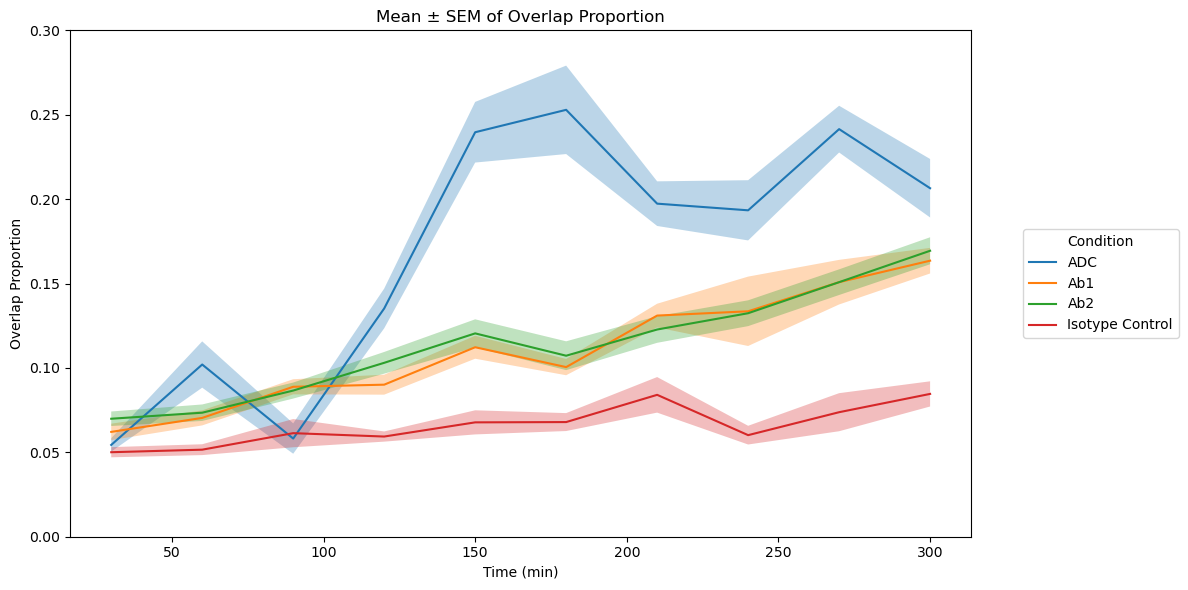

In [5]:
df1='/net/bmc-lab8/data/lab/boyer/users/jhday/Sanofi Paper/June2026_Submission/data/Volumetric_Proportion_Result_Experiment_1.csv'
df1=pd.read_csv(df1)
df2='/net/bmc-lab8/data/lab/boyer/users/jhday/Sanofi Paper/June2026_Submission/data/Volumetric_Proportion_Result_Experiment_2.csv'
df2=pd.read_csv(df2)
plot_mean_sem_lineplot([df1,df2])

In [33]:
def joyplot_replicates(
    dataframes,
    y_col,
    bins=50,
    overlap=0.5,
    figsize=(12, 8),
    colormap=plt.cm.viridis,
    y_lim=None,
    data_range=None,
    invert=True,
    save=None
    ):
    """
    Plots stacked mean ± SEM histograms (joyplot style) from replicate dataframes.
    Falls back to a regular histogram plot when only one timepoint is present.

    Parameters
    ----------
    dataframes : list[pd.DataFrame]
        List of dataframes from multiple replicates.
    y_col : str
        Column to plot histograms for.
    bins : int
        Number of histogram bins.
    overlap : float
        Vertical spacing between stacked histograms.
    figsize : tuple
        Figure size.
    colormap : colormap
        Colormap for timepoints.
    data_range : tuple or None
        (min, max) range for histogram binning. If None, uses full data range.
    """
        
    df = pd.concat(dataframes, ignore_index=True)
        
    time_order = sorted(df["Time"].dropna().unique())
    num_timepoints = len(time_order)
    colors = colormap(np.linspace(0, 1, num_timepoints))

    if data_range is None:
        data_range = (df[y_col].min(), df[y_col].max())
    bin_edges = np.linspace(data_range[0], data_range[1], bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    fig, ax = plt.subplots(figsize=figsize)


    time = time_order[0]
    subset = df[df["Time"] == time]
    replicate_means = []
    for rep in subset["Replicate"].unique():
        rep_data = subset[subset["Replicate"] == rep][y_col]
        counts, _ = np.histogram(rep_data, bins=bin_edges)
        replicate_means.append(counts)
    replicate_means = np.array(replicate_means)
    mean_counts = replicate_means.mean(axis=0)
    sem_counts = sem(replicate_means, axis=0, nan_policy="omit")

    # Normalize to density
    total_counts = replicate_means.sum()
    if total_counts == 0:
        print(f"No data for timepoint {time}. Skipping.")
        return df, ax

    mean_counts = mean_counts / total_counts
    sem_counts = sem_counts / total_counts

    # Plot standard histogram
    ax.plot(bin_centers, mean_counts, color=colors[0], lw=2)
    ax.fill_between(
        bin_centers,
        mean_counts - sem_counts,
        mean_counts + sem_counts,
        color=colors[0],
        alpha=0.3
    )

    ax.set_title(f"Histogram for Time = {time}")
    if y_lim:
        ax.set_ylim(y_lim)
    ax.set_xlabel(y_col)
    ax.set_ylabel("Probability Density")

    plt.tight_layout()
    if save:
        plt.savefig(save)
    plt.show()

    return df, ax

import numpy as np
import pandas as pd
from scipy.stats import gmean


def summarize_replicates(
    df_experiment_1,
    df_experiment_2,
    value_col='mean_intensity',
    condition_col="Condition",
    timepoint_col="Time",
    replicate_col="Replicate",
    upper_tail_threshold=None,
    upper_tail_percentile=.95,
    ):

    # -------------------------------------------------------------
    # 1. Concatenate the two input dataframes
    # -------------------------------------------------------------
    combined_df = pd.concat(
        [df_experiment_1, df_experiment_2],
        ignore_index=True,
    )

    required_columns = {
        condition_col,
        timepoint_col,
        replicate_col,
        value_col,
    }

    missing_columns = required_columns.difference(combined_df.columns)

    if missing_columns:
        raise KeyError(
            f"Required columns are missing: {sorted(missing_columns)}"
        )

    # -------------------------------------------------------------
    # 2. Build the structure of the output dataframe
    # -------------------------------------------------------------
    grouping_columns = [
        condition_col,
        timepoint_col,
        replicate_col,
    ]

    summary_df = (
        combined_df[grouping_columns]
        .drop_duplicates()
        .sort_values(grouping_columns)
        .reset_index(drop=True)
    )

    # Create empty quantification columns
    summary_df["Geometric Mean"] = np.nan
    summary_df["Upper Tail Ratio"] = np.nan
    summary_df["Median"] = np.nan
    summary_df["Number of Values"] = 0

    # -------------------------------------------------------------
    # 3. Iterate through each output row
    # -------------------------------------------------------------
    for row_index, row in summary_df.iterrows():

        condition = row[condition_col]
        timepoint = row[timepoint_col]
        replicate = row[replicate_col]

        # Select all data associated with this unique combination
        row_mask = (
            (combined_df[condition_col] == condition)
            & (combined_df[timepoint_col] == timepoint)
            & (combined_df[replicate_col] == replicate)
        )

        replicate_data = combined_df.loc[row_mask, value_col]

        # Convert to numeric and remove NaN/infinite values
        values = pd.to_numeric(
            replicate_data,
            errors="coerce",
        ).to_numpy(dtype=float)

        values = values[np.isfinite(values)]

        if values.size == 0:
            continue

        # ---------------------------------------------------------
        # Calculate the median
        # ---------------------------------------------------------
        median_value = np.median(values)

        # ---------------------------------------------------------
        # Calculate the geometric mean
        #
        # scipy.stats.gmean requires positive values. Zero and
        # negative values are excluded here.
        # ---------------------------------------------------------
        positive_values = values[values > 0]

        if positive_values.size > 0:
            geometric_mean = gmean(positive_values)
        else:
            geometric_mean = np.nan

        # ---------------------------------------------------------
        # Calculate the upper-tail ratio
        # ---------------------------------------------------------
        q25, q50, q75, q_hi = np.quantile(values, [0.25, 0.5, 0.75, upper_tail_percentile])
        iqr = q75 - q25
        if iqr == 0:
            upper_tail_ratio=0
        else:
            upper_tail_ratio=(q_hi - q50) / iqr

        # ---------------------------------------------------------
        # Populate the appropriate output cells
        # ---------------------------------------------------------
        summary_df.loc[
            row_index,
            "Geometric Mean",
        ] = geometric_mean

        summary_df.loc[
            row_index,
            "Upper Tail Ratio",
        ] = upper_tail_ratio

        summary_df.loc[
            row_index,
            "Median",
        ] = median_value

        summary_df.loc[
            row_index,
            "Number of Values",
        ] = values.size

    return summary_df

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem


def plot_replicate_summary(
    summary_df,
    metric,
    conditions=None,
    timepoints=None,
    condition_col="Condition",
    timepoint_col="Time",
    replicate_col="Replicate",
    condition_order=None,
    timepoint_order=None,
    figsize=(6, 5),
    capsize=5,
    point_size=45,
    jitter=0.06,
    ylim=None,
    random_seed=1,
    ylabel=None,
    title=None,
    save_path=None,
    dpi=300,
    ):
    """
    Plot mean ± SEM bars with individual replicate values overlaid.

    Each row of summary_df should represent one independent replicate
    for one Condition-Timepoint combination.
    """

    required_columns = {
        condition_col,
        timepoint_col,
        replicate_col,
        metric,
    }

    missing_columns = required_columns.difference(summary_df.columns)

    if missing_columns:
        raise KeyError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    data = summary_df.copy()

    # Convert single selections into lists.
    if conditions is not None:
        if isinstance(conditions, str) or not hasattr(conditions, "__iter__"):
            conditions = [conditions]

        data = data[data[condition_col].isin(conditions)]

    if timepoints is not None:
        if isinstance(timepoints, str) or not hasattr(timepoints, "__iter__"):
            timepoints = [timepoints]

        data = data[data[timepoint_col].isin(timepoints)]

    data[metric] = pd.to_numeric(data[metric], errors="coerce")
    data = data.dropna(subset=[metric])

    if data.empty:
        raise ValueError("No data remain after applying the filters.")

    # Confirm that each replicate has only one value per group.
    duplicate_groups = data.duplicated(
        subset=[condition_col, timepoint_col, replicate_col],
        keep=False,
    )

    if duplicate_groups.any():
        duplicate_rows = (
            data.loc[
                duplicate_groups,
                [condition_col, timepoint_col, replicate_col],
            ]
            .drop_duplicates()
        )

        raise ValueError(
            "Multiple rows were found for these "
            "Condition-Timepoint-Replicate combinations:\n"
            f"{duplicate_rows}"
        )

    # Calculate mean and SEM across replicate-level values.
    plot_data = (
        data.groupby(
            [condition_col, timepoint_col],
            observed=True,
        )[metric]
        .agg(
            Mean="mean",
            SEM=lambda values: (
                sem(values, nan_policy="omit")
                if values.notna().sum() > 1
                else np.nan
            ),
            N="count",
        )
        .reset_index()
    )

    # Determine plotting order.
    if condition_order is None:
        condition_order = (
            list(conditions)
            if conditions is not None
            else list(data[condition_col].drop_duplicates())
        )

    if timepoint_order is None:
        timepoint_order = (
            list(timepoints)
            if timepoints is not None
            else list(data[timepoint_col].drop_duplicates())
        )

    available_conditions = set(data[condition_col])
    available_timepoints = set(data[timepoint_col])

    condition_order = [
        value for value in condition_order
        if value in available_conditions
    ]

    timepoint_order = [
        value for value in timepoint_order
        if value in available_timepoints
    ]

    fig, ax = plt.subplots(figsize=figsize)

    x_positions = np.arange(len(condition_order))
    number_of_timepoints = len(timepoint_order)

    total_group_width = 0.8
    bar_width = total_group_width / number_of_timepoints

    rng = np.random.default_rng(random_seed)

    for timepoint_index, timepoint in enumerate(timepoint_order):

        means = []
        errors = []

        offset = (
            timepoint_index - (number_of_timepoints - 1) / 2
        ) * bar_width

        group_x_positions = x_positions + offset

        for condition in condition_order:
            group_summary = plot_data[
                (plot_data[condition_col] == condition)
                & (plot_data[timepoint_col] == timepoint)
            ]

            if group_summary.empty:
                means.append(np.nan)
                errors.append(np.nan)
            else:
                means.append(group_summary["Mean"].iloc[0])
                errors.append(group_summary["SEM"].iloc[0])

        # Mean ± SEM bars
        ax.bar(
            group_x_positions,
            means,
            width=bar_width,
            yerr=errors,
            capsize=capsize,
            label=str(timepoint),
            alpha=0.7,
            edgecolor="black",
            linewidth=1,
            zorder=1,
        )
        if ylim!=None:
            ax.set_ylim(ylim)

        # Individual replicate values
        for condition_index, condition in enumerate(condition_order):

            replicate_values = data.loc[
                (data[condition_col] == condition)
                & (data[timepoint_col] == timepoint),
                metric,
            ].to_numpy(dtype=float)

            replicate_x = np.full(
                replicate_values.size,
                group_x_positions[condition_index],
                dtype=float,
            )

            if replicate_values.size > 1:
                replicate_x += rng.uniform(
                    -jitter,
                    jitter,
                    size=replicate_values.size,
                )

            ax.scatter(
                replicate_x,
                replicate_values,
                s=point_size,
                edgecolor="black",
                linewidth=0.8,
                zorder=3,
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(condition_order)

    ax.set_xlabel(condition_col)
    ax.set_ylabel(ylabel if ylabel is not None else metric)

    if title is None:
        ax.set_title(f"{metric} by condition and timepoint")
    else:
        ax.set_title(title)

    if number_of_timepoints > 1:
        ax.legend(title=timepoint_col)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
        )

    return fig, ax, plot_data

def pairwise_ttests(
    df,
    group_col="condition",
    value_col = "q_val",
    equal_var = False,          # False = Welch's t-test (recommended)
    correction= "holm",  # None, "bonferroni", "holm", "fdr_bh"
    dropna = True
    ):
    """
    Pairwise t-tests between all levels of `group_col` on `value_col`.

    Returns a DataFrame with:
      group1, group2, n1, n2, mean1, mean2, t, p, p_adj (if correction)
    """
    d = df[[group_col, value_col]].copy()
    if dropna:
        d = d.dropna(subset=[group_col, value_col])

    groups = list(d[group_col].unique())
    rows = []

    for g1, g2 in combinations(groups, 2):
        x1 = d.loc[d[group_col] == g1, value_col].to_numpy(dtype=float)
        x2 = d.loc[d[group_col] == g2, value_col].to_numpy(dtype=float)

        t, p = ttest_ind(x1, x2, equal_var=equal_var, nan_policy="omit")
        rows.append({
            "metric": value_col,
            "group1": g1, "group2": g2,
            "n1": len(x1), "n2": len(x2),
            "mean1": np.mean(x1), "mean2": np.mean(x2),
            "t": t, "p": p,
        })

    res = pd.DataFrame(rows)

    # Multiple-comparisons correction
    if correction is not None and len(res) > 0:
        try:
            from statsmodels.stats.multitest import multipletests
            method_map = {"bonferroni": "bonferroni", "holm": "holm", "fdr_bh": "fdr_bh"}
            method = method_map.get(correction, correction)
            res["p_adj"] = multipletests(res["p"].values, method=method)[1]
        except Exception:
            # Fallback: Bonferroni only
            if correction == "bonferroni":
                res["p_adj"] = np.minimum(res["p"] * len(res), 1.0)

    return res.sort_values("p_adj" if "p_adj" in res.columns else "p")

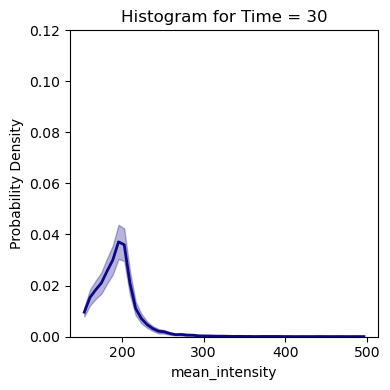

(       Unnamed: 0  mean_intensity  Time Condition  Replicate
 0          120289      176.026438    30       Ab2          1
 1          120290      196.014674    30       Ab2          1
 2          120291      146.462031    30       Ab2          1
 3          120292      149.090376    30       Ab2          1
 4          120293      260.381383    30       Ab2          1
 ...           ...             ...   ...       ...        ...
 26829      259023      204.551499    30       Ab2          4
 26830      259024      192.383392    30       Ab2          4
 26831      259025      216.810367    30       Ab2          4
 26832      259026      198.453955    30       Ab2          4
 26833      259027      168.703582    30       Ab2          4
 
 [26834 rows x 5 columns],
 <Axes: title={'center': 'Histogram for Time = 30'}, xlabel='mean_intensity', ylabel='Probability Density'>)

In [43]:
df1='/net/bmc-lab8/data/lab/boyer/users/jhday/Sanofi Paper/June2026_Submission/data/Object_Based_Colocalization_Result_Experiment_1.csv'
df2='/net/bmc-lab8/data/lab/boyer/users/jhday/Sanofi Paper/June2026_Submission/data/Object_Based_Colocalization_Result_Experiment_2.csv'
df1=pd.read_csv(df1)
df2=pd.read_csv(df2)

condition='Ab2'
time = 30
df1=df1[df1['Condition']==condition]
df1=df1[df1['Time']==time]

df2=df2[df2['Condition']==condition]
df2=df2[df2['Time']==time]

joyplot_replicates(
    [df1, df2],
    y_col="mean_intensity",
    bins=50,
    colormap=plt.cm.plasma,
    data_range=(150,500),
    figsize=(4,4),
    y_lim=(0,0.12),
    save=f'/net/bmc-lab8/data/lab/boyer/users/jhday/Sanofi Paper/Figure 2/{condition}{str(time)}.svg'
)


In [5]:
df1='/net/bmc-lab8/data/lab/boyer/users/jhday/Sanofi Paper/June2026_Submission/data/Object_Based_Colocalization_Result_Experiment_1.csv'
df2='/net/bmc-lab8/data/lab/boyer/users/jhday/Sanofi Paper/June2026_Submission/data/Object_Based_Colocalization_Result_Experiment_2.csv'
df1=pd.read_csv(df1)
df2=pd.read_csv(df2)
summdf = summarize_replicates(df1,df2)

In [59]:
summdf

,Condition,Time,Replicate,Geometric Mean,Upper Tail Ratio,Median,Number of Values
0,ADC,30,1,182.373254,0.990226,184.778302,10996
1,ADC,30,2,178.587223,0.697460,182.571988,1949
2,ADC,30,3,204.275911,2.990373,199.553433,4414
3,ADC,30,4,215.153631,3.867865,203.615110,5706
4,ADC,60,1,183.841763,1.109409,185.485080,7411
...,...,...,...,...,...,...,...
154,Isotype Control,270,4,176.574546,0.681185,180.245161,7591
155,Isotype Control,300,1,177.704027,0.690263,181.870227,7612
156,Isotype Control,300,2,179.826767,0.678089,184.212371,5531
157,Isotype Control,300,3,176.022696,0.713190,179.725227,7699


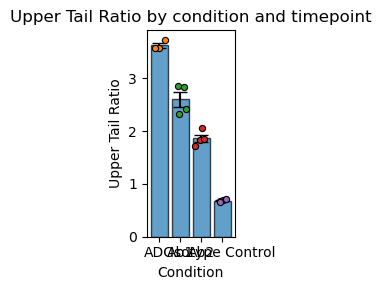

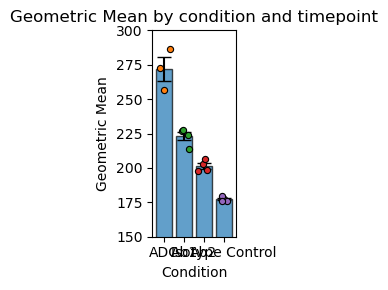

In [18]:
plot_replicate_summary(summdf,'Upper Tail Ratio',conditions=['ADC','Ab1','Ab2','Isotype Control'],timepoints=300,figsize=(2,3),point_size=20,jitter=0.3)
plot_replicate_summary(summdf,'Geometric Mean',conditions=['ADC','Ab1','Ab2','Isotype Control'],timepoints=300,figsize=(2,3),point_size=20,jitter=0.3,ylim=(150,300))

In [24]:
cond1='ADC'
cond2='Ab1'
cond3='Ab2'
cond4='Isotype Control'
time = '300'
metric='Geometric Mean'
# metric='Upper Tail Ratio'

con1=cond3
con2=cond4

values_condition_1 = summdf.loc[
                    (summdf["Condition"] == con1)& (summdf["Time"].astype(str) == str(time)),
                            metric].to_numpy()
values_condition_2 = summdf.loc[
                    (summdf["Condition"] == con2)& (summdf["Time"].astype(str) == str(time)),
                            metric].to_numpy()


result = ttest_ind(
    values_condition_1,
    values_condition_2,
    equal_var=False,       # Welch's t test
    alternative="two-sided"
)

print("t statistic:", result.statistic)
print("p value:", result.pvalue)

t statistic: 10.715501704175194
p value: 0.0003946073776076644
